# Домашнее задание 3. Сверточные нейронные сети (CNN)

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1–4 | 3 (0.75 за задачу) |
| **Средние** | 5–7 | 3 (1 за задачу) |
| **Сложные** | 8–9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cpu


---

## Теоретический минимум

### Почему для изображений нужны специальные архитектуры

Полносвязные сети (MLP) не учитывают пространственную структуру данных.
Для изображения размером $H \times W \times C$ полносвязный слой требует
$H \cdot W \cdot C \cdot N_{out}$ параметров, это быстро становится неуправляемым.

CNN используют три ключевые идеи:
- **Локальные связи**: каждый нейрон связан только с небольшой областью входа.
- **Разделение параметров** (parameter sharing): одно ядро применяется ко всем позициям.
- **Эквивариантность к сдвигу**: сдвиг входа приводит к аналогичному сдвигу карты признаков.

### Операция свертки

Дискретная двумерная свертка с ядром размера $K \times K$:

$$(f * g)(i, j) = \sum_{m=0}^{K-1}\sum_{n=0}^{K-1} f(m,n)\,g(i+m,\,j+n)$$

Результат — **карта признаков** (feature map).

### Формула размера выхода

$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

где $P$ — padding, $K$ — размер ядра, $S$ — stride.

### Padding

- **valid** ($P=0$): размер уменьшается при каждой свертке.
- **same** ($P = \lfloor K/2 \rfloor$ при $S=1$): размер сохраняется.

### Stride

Шаг $S > 1$ уменьшает пространственное разрешение — альтернатива pooling.

### Pooling

- **Max Pooling** — берет максимум в окне (выделяет наиболее активный признак).
- **Average Pooling** — среднее в окне (сглаживает).

Pooling уменьшает разрешение и дает **локальную инвариантность** к малым сдвигам.

### Каналы и число параметров

Для свертки с $C_{in}$ входных и $C_{out}$ выходных каналов, ядром $K \times K$:

$$N_{params} = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$$

### Receptive field

Рецептивное поле — область входного изображения, влияющая на один элемент
выходной карты признаков. Растет с глубиной сети.

### Эквивариантность и инвариантность

- **Эквивариантность к сдвигу**: свертка гарантирует, что сдвиг входа порождает
  такой же сдвиг карты признаков.
- **Инвариантность**: достигается через pooling и глобальное усреднение.

### Задачи компьютерного зрения

| Задача | Вход | Выход |
|--------|------|-------|
| Классификация | Изображение | Метка класса |
| Детекция | Изображение | Bounding boxes + классы |
| Сегментация | Изображение | Маска (класс для каждого пикселя) |


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание базовых элементов CNN: свертка, padding, stride, pooling, подсчет параметров.

## Задача 1. Формула размера выхода свертки

### Постановка задачи

Реализуйте функцию, вычисляющую размер выхода сверточного/pooling слоя,
и проверьте ее на нескольких тестовых случаях.

**Формула:**
$$H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$$

### Задача
1. Реализуйте `conv_output_size(h_in, k, p, s)`.
2. Проверьте на 5 случаях: (32,3,0,1), (32,3,1,1), (32,5,0,2), (28,3,1,2), (224,7,3,2).
3. Реализуйте `pool_output_size` (по умолчанию stride = kernel_size).
4. Сверьте с `nn.Conv2d` / `nn.MaxPool2d`.


In [2]:
# Задача 1. Расчёт выходных размеров свёрток

# Формула: H_out = floor((H_in + 2P - K) / S) + 1
def conv_output_size(h_in, k, p=0, s=1):
    """Вычисляет H_out по формуле свёртки."""
    return math.floor((h_in + 2 * p - k) / s) + 1


def pool_output_size(h_in, k, p=0, s=None):
    """Размер после pooling (stride по умолчанию = kernel_size)."""
    if s is None:
        s = k
    return math.floor((h_in + 2 * p - k) / s) + 1


# --- Тестовые кейсы (h_in, k, p, s, expected) ---
# Ручной расчёт:
# 1) (32-3+0)/1 + 1 = 30
# 2) (32-3+2)/1 + 1 = 32   (same padding)
# 3) (32-5+0)/2 + 1 = 14   (floor(27/2)+1)
# 4) (28-3+2)/2 + 1 = 14   (floor(27/2)+1)
# 5) (224-7+6)/2 + 1 = 112  (floor(223/2)+1)
cases = [
    (32, 3, 0, 1, 30),
    (32, 3, 1, 1, 32),
    (32, 5, 0, 2, 14),
    (28, 3, 1, 2, 14),
    (224, 7, 3, 2, 112),
]

print("Проверка формулы выходных размеров свёрток:")
print("-" * 65)

for i, (h, k, p, s, exp) in enumerate(cases, 1):
    result = conv_output_size(h, k, p, s)
    status = "+" if result == exp else "-"
    print(f"  {i}. h_in={h:>3}, k={k}, p={p}, s={s}  →  H_out={result:>3}  (ожидание {exp})  [{status}]")


# Валидация через PyTorch nn.Conv2d
print("\nСверка с PyTorch nn.Conv2d:")
print("-" * 65)

with torch.no_grad():
    for i, (h, k, p, s, exp) in enumerate(cases, 1):
        conv = nn.Conv2d(1, 1, kernel_size=k, padding=p, stride=s)
        x = torch.randn(1, 1, h, h)
        h_out_pt = conv(x).shape[2]
        status = "+" if h_out_pt == exp else "-"
        print(f"  {i}. Conv2d(k={k},p={p},s={s}) на входе {h}×{h}  →  {h_out_pt}×{h_out_pt}  [{status}]")

# Дополнительно: проверка pool_output_size
print("\nПроверка pool_output_size:")
print("-" * 65)
pool_cases = [(32, 2, 0, None, 16), (14, 2, 0, None, 7), (112, 2, 0, None, 56)]
with torch.no_grad():
    for i, (h, k, p, s, exp) in enumerate(pool_cases, 1):
        result = pool_output_size(h, k, p, s)
        pool = nn.MaxPool2d(kernel_size=k, padding=p, stride=k if s is None else s)
        x = torch.randn(1, 1, h, h)
        h_pt = pool(x).shape[2]
        status = "+" if result == exp == h_pt else "-"
        print(f"  {i}. Pool(k={k}) на входе {h}×{h}  →  формула={result}, PyTorch={h_pt}  [{status}]")

Проверка формулы выходных размеров свёрток:
-----------------------------------------------------------------
  1. h_in= 32, k=3, p=0, s=1  →  H_out= 30  (ожидание 30)  [+]
  2. h_in= 32, k=3, p=1, s=1  →  H_out= 32  (ожидание 32)  [+]
  3. h_in= 32, k=5, p=0, s=2  →  H_out= 14  (ожидание 14)  [+]
  4. h_in= 28, k=3, p=1, s=2  →  H_out= 14  (ожидание 14)  [+]
  5. h_in=224, k=7, p=3, s=2  →  H_out=112  (ожидание 112)  [+]

Сверка с PyTorch nn.Conv2d:
-----------------------------------------------------------------
  1. Conv2d(k=3,p=0,s=1) на входе 32×32  →  30×30  [+]
  2. Conv2d(k=3,p=1,s=1) на входе 32×32  →  32×32  [+]
  3. Conv2d(k=5,p=0,s=2) на входе 32×32  →  14×14  [+]
  4. Conv2d(k=3,p=1,s=2) на входе 28×28  →  14×14  [+]
  5. Conv2d(k=7,p=3,s=2) на входе 224×224  →  112×112  [+]

Проверка pool_output_size:
-----------------------------------------------------------------
  1. Pool(k=2) на входе 32×32  →  формула=16, PyTorch=16  [+]
  2. Pool(k=2) на входе 14×14  →  формула=7,

---

## Задача 2. Подсчет параметров свертки

### Постановка задачи

Сравните число параметров сверточного и полносвязного слоев при одинаковых
входных/выходных размерностях.

**Формулы:**
- Conv: $N = K^2 \cdot C_{in} \cdot C_{out} + C_{out}$
- FC: $N = N_{in} \cdot N_{out} + N_{out}$

### Задача
1. Реализуйте `count_conv_params` и `count_fc_params`.
2. Сравните для входа 32x32x3 с выходом 32x32x16.
3. Покажите преимущество parameter sharing.


In [3]:
# Задача 2. Подсчёт параметров свёрток

# Conv2d: N = K² · C_in · C_out + C_out (bias)
# Linear:  N = N_in · N_out + N_out (bias)
def count_conv_params(c_in, c_out, k, bias=True):
    """Число параметров Conv2d."""
    # Каждый фильтр: K×K×C_in весов, один bias на выходной канал
    return k * k * c_in * c_out + (c_out if bias else 0)


def count_fc_params(n_in, n_out, bias=True):
    """Число параметров Linear."""
    return n_in * n_out + (n_out if bias else 0)


# --- Сравнение: Conv vs FC для входа 32×32×3 → выхода 32×32×16 ---
# Conv2d(3, 16, 3, padding=1): 3²·3·16 + 16 = 432 + 16 = 448
# Linear(32*32*3, 32*32*16):   3072·16384 + 16384 = 50_331_648 + 16_384 = 50_348_032

conv_p = count_conv_params(3, 16, 3)
fc_p   = count_fc_params(32 * 32 * 3, 32 * 32 * 16)

print("Расчётное число параметров:")
print(f"  Conv2d(3→16, k=3):  {conv_p:>12,}")
print(f"  Linear(3072→16384): {fc_p:>12,}")
print(f"  Сокращение благодаря parameter sharing: ×{fc_p / conv_p:,.0f}")

# Верификация через PyTorch
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)
fc   = nn.Linear(32 * 32 * 3, 32 * 32 * 16)

conv_actual = sum(p.numel() for p in conv.parameters())
fc_actual   = sum(p.numel() for p in fc.parameters())

print("\nПроверка через PyTorch:")
print(f"  Conv2d: расчёт={conv_p}, PyTorch={conv_actual}  [{'+' if conv_p == conv_actual else '-'}]")
print(f"  Linear: расчёт={fc_p}, PyTorch={fc_actual}  [{'+' if fc_p == fc_actual else '-'}]")

# Детализация по тензорам
print("\nСтруктура параметров Conv2d(3→16, k=3):")
for name, p in conv.named_parameters():
    print(f"  {name}: shape={list(p.shape)}, numel={p.numel()}")

Расчётное число параметров:
  Conv2d(3→16, k=3):           448
  Linear(3072→16384):   50,348,032
  Сокращение благодаря parameter sharing: ×112,384

Проверка через PyTorch:
  Conv2d: расчёт=448, PyTorch=448  [+]
  Linear: расчёт=50348032, PyTorch=50348032  [+]

Структура параметров Conv2d(3→16, k=3):
  weight: shape=[16, 3, 3, 3], numel=432
  bias: shape=[16], numel=16


---

## Задача 3. CNN и отслеживание размерностей

### Постановка задачи

Постройте CNN для входа 1x28x28 (MNIST) и пропустите через нее случайный тензор,
выводя размерность на каждом слое.

### Архитектура
```
Input(1, 28, 28)
  -> Conv2d(1, 16, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Conv2d(16, 32, 3, padding=1) -> ReLU -> MaxPool2d(2)
  -> Flatten
  -> Linear(32*7*7, 10)
```

### Задача
1. Реализуйте модель с печатью shape в forward.
2. Пропустите батч (4, 1, 28, 28) и проверьте размерности.
3. Выведите общее число параметров.


In [4]:
# Задача 3. CNN с отслеживанием размерностей
#
# Архитектура для MNIST (1×28×28):
#   Input(1,28,28)
#     → Conv2d(1,16,3,p=1) → ReLU → MaxPool(2)    # (B,16,14,14)
#     → Conv2d(16,32,3,p=1) → ReLU → MaxPool(2)   # (B,32,7,7)
#     → Flatten                                      # (B,1568)
#     → Linear(1568,10)                              # (B,10)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x, verbose=False):
        if verbose:
            print(f"  Input:       {list(x.shape)}")

        x = self.pool(F.relu(self.conv1(x)))        # (B,16,14,14)
        if verbose:
            print(f"  Conv1+Pool:  {list(x.shape)}")

        x = self.pool(F.relu(self.conv2(x)))         # (B,32,7,7)
        if verbose:
            print(f"  Conv2+Pool:  {list(x.shape)}")

        x = x.flatten(start_dim=1)                   # (B,1568)
        if verbose:
            print(f"  Flatten:     {list(x.shape)}")

        x = self.fc(x)                                # (B,10)
        if verbose:
            print(f"  FC output:   {list(x.shape)}")
        return x


model = SimpleCNN()
x = torch.randn(4, 1, 28, 28)

print("Размерности тензоров через всю сеть:")
out = model(x, verbose=True)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nОбщее число параметров: {total_params:,}")

# Детализация по слоям
print("\nПараметры по слоям:")
for name, p in model.named_parameters():
    print(f"  {name:20s}  shape={str(list(p.shape)):20s}  numel={p.numel():>6,}")

Размерности тензоров через всю сеть:
  Input:       [4, 1, 28, 28]
  Conv1+Pool:  [4, 16, 14, 14]
  Conv2+Pool:  [4, 32, 7, 7]
  Flatten:     [4, 1568]
  FC output:   [4, 10]

Общее число параметров: 20,490

Параметры по слоям:
  conv1.weight          shape=[16, 1, 3, 3]         numel=   144
  conv1.bias            shape=[16]                  numel=    16
  conv2.weight          shape=[32, 16, 3, 3]        numel= 4,608
  conv2.bias            shape=[32]                  numel=    32
  fc.weight             shape=[10, 1568]            numel=15,680
  fc.bias               shape=[10]                  numel=    10


---

## Задача 4. Визуализация фильтров и карт признаков

### Постановка задачи

Создайте синтетическое изображение, примените к нему ручные фильтры
(детектор вертикальных краев, горизонтальных краев, размытие) и
визуализируйте результаты.

### Задача
1. Сгенерируйте изображение 28x28 с прямоугольником.
2. Определите три фильтра 3x3: вертикальные края, горизонтальные края, размытие.
3. Примените свертку (`F.conv2d`).
4. Визуализируйте оригинал и три карты признаков.


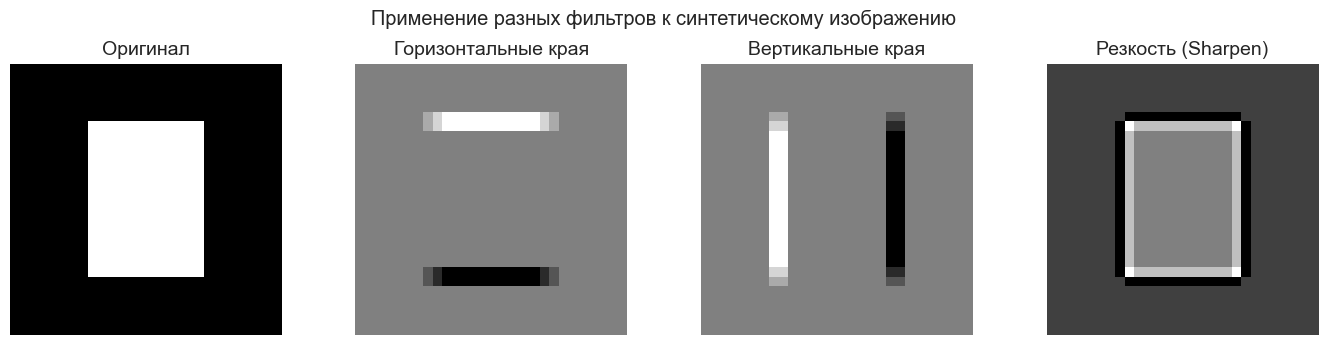

In [5]:
# Задача 4. Визуализация свёрток с ядрами фильтров

# Синтетическое изображение: белый прямоугольник на чёрном фоне
img = np.zeros((28, 28), dtype=np.float32)
img[6:22, 8:20] = 1.0
img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # (1, 1, 28, 28)

# Классические ядра 3×3 для выделения признаков
filters = {
    "Горизонтальные края": torch.tensor([[-1., -1., -1.],
                                           [ 0.,  0.,  0.],
                                           [ 1.,  1.,  1.]]),
    "Вертикальные края":   torch.tensor([[-1., 0., 1.],
                                           [-1., 0., 1.],
                                           [-1., 0., 1.]]),
    "Резкость (Sharpen)":  torch.tensor([[ 0., -1.,  0.],
                                           [-1.,  5., -1.],
                                           [ 0., -1.,  0.]]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Оригинал")
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], filters.items()):
    # Формируем 4D-тензор ядра: (C_out=1, C_in=1, H=3, W=3)
    weight = kernel.unsqueeze(0).unsqueeze(0)
    # Применяем свёртку с padding=1 для сохранения размерности
    feature_map = F.conv2d(img_tensor, weight, padding=1)
    # Визуализируем карту активаций
    ax.imshow(feature_map.squeeze().detach().numpy(), cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle("Применение разных фильтров к синтетическому изображению")
plt.tight_layout()
plt.show()

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Комбинирование концепций: обучение CNN, абляционные эксперименты.

## Задача 5. Классификация FashionMNIST

### Постановка задачи

Обучите CNN-классификатор на датасете FashionMNIST.

### Архитектура
```
Conv2d(1,32,3,p=1)->ReLU->MaxPool(2)
->Conv2d(32,64,3,p=1)->ReLU->MaxPool(2)
->Flatten->Linear(64*7*7,128)->ReLU->Linear(128,10)
```

### Задача
1. Загрузите FashionMNIST, разделите train на train/val (50000/10000).
2. Обучите модель (10 эпох, Adam, lr=0.001, batch_size=64).
3. Постройте кривые обучения (loss, accuracy).
4. Выведите accuracy на тесте и confusion matrix.


Epoch  1/10  train_loss=0.4327  train_acc=0.8418  val_loss=0.3473  val_acc=0.8746
Epoch  2/10  train_loss=0.2791  train_acc=0.8975  val_loss=0.2666  val_acc=0.9030
Epoch  3/10  train_loss=0.2296  train_acc=0.9156  val_loss=0.2494  val_acc=0.9077
Epoch  4/10  train_loss=0.1981  train_acc=0.9278  val_loss=0.2322  val_acc=0.9160
Epoch  5/10  train_loss=0.1700  train_acc=0.9376  val_loss=0.2322  val_acc=0.9165
Epoch  6/10  train_loss=0.1456  train_acc=0.9463  val_loss=0.2180  val_acc=0.9254
Epoch  7/10  train_loss=0.1248  train_acc=0.9539  val_loss=0.2217  val_acc=0.9255
Epoch  8/10  train_loss=0.1048  train_acc=0.9609  val_loss=0.2464  val_acc=0.9186
Epoch  9/10  train_loss=0.0860  train_acc=0.9686  val_loss=0.2499  val_acc=0.9196
Epoch 10/10  train_loss=0.0710  train_acc=0.9739  val_loss=0.2739  val_acc=0.9199


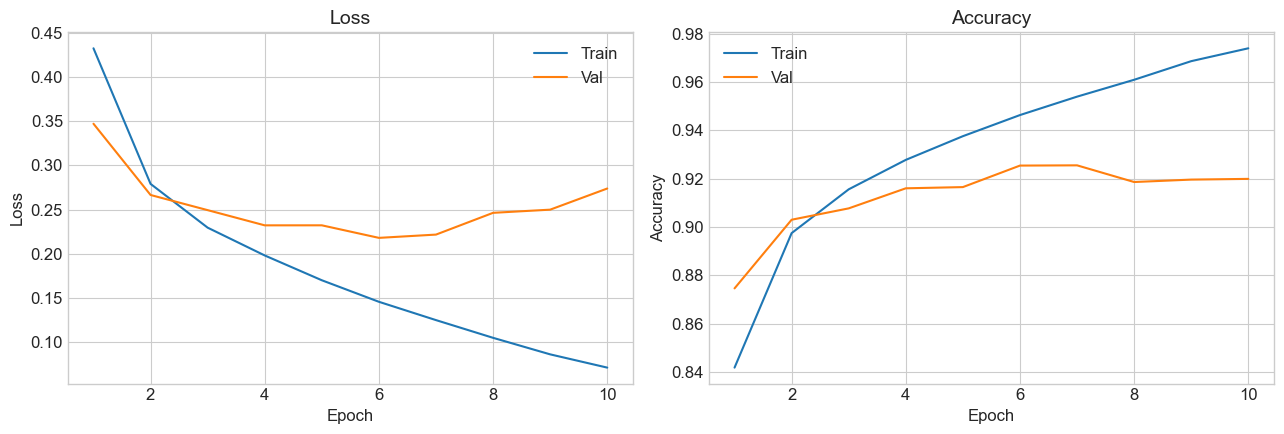


Accuracy на тесте: 0.9122


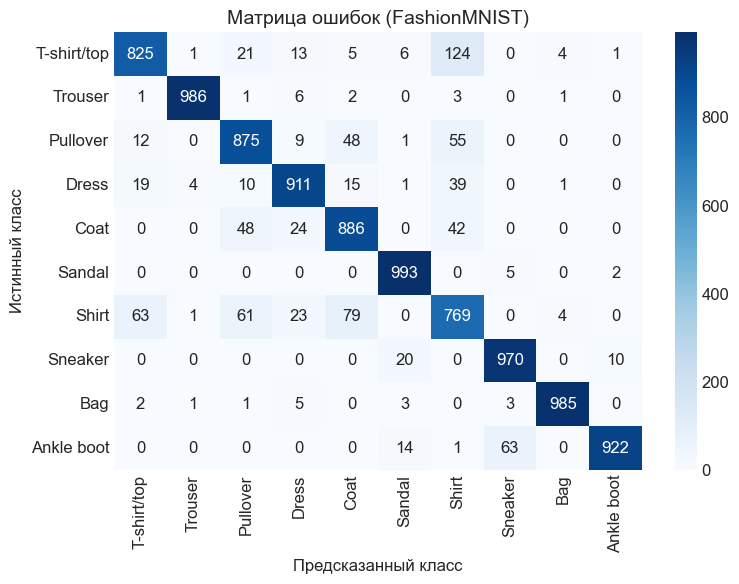

In [6]:
# Задача 5. Классификация FashionMNIST

torch.manual_seed(SEED)

# --- Данные ---
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_ds    = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_ds, val_ds = torch.utils.data.random_split(train_full, [50000, 10000],
                                                   generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- Модель ---
# Conv2d(1,32,3,p=1)->ReLU->MaxPool(2)          => (B,32,14,14)
# Conv2d(32,64,3,p=1)->ReLU->MaxPool(2)         => (B,64,7,7)
# Flatten->Linear(64*7*7,128)->ReLU->Linear(128,10)

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)       # (B,64,7,7)
        x = x.flatten(start_dim=1) # (B,3136)
        return self.classifier(x)  # (B,10)

model = FashionCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Обучение ---
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(10):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += X_batch.size(0)
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(correct / total)

    # --- Val ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item() * X_batch.size(0)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)
    history['val_loss'].append(val_loss / total)
    history['val_acc'].append(correct / total)

    print(f"Epoch {epoch+1:>2}/10  "
          f"train_loss={history['train_loss'][-1]:.4f}  train_acc={history['train_acc'][-1]:.4f}  "
          f"val_loss={history['val_loss'][-1]:.4f}  val_acc={history['val_acc'][-1]:.4f}")

# --- Графики ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, 11)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

# --- Тест ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.tolist())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy на тесте: {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс'); plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (FashionMNIST)'); plt.tight_layout(); plt.show()

---

## Задача 6. MaxPool vs Strided Conv (абляция)

### Постановка задачи

Сравните два способа уменьшения пространственного разрешения:
MaxPool2d(2) и Conv2d с stride=2.

### Задача
1. Реализуйте две модели с одинаковой структурой, но разным downsampling.
2. Обучите обе на FashionMNIST (5 эпох).
3. Сравните: число параметров, test accuracy.
4. Постройте график accuracy обеих моделей.


--- Вариант A: MaxPool ---
  Epoch 1/5  val_acc=0.8746
  Epoch 2/5  val_acc=0.9030
  Epoch 3/5  val_acc=0.9077
  Epoch 4/5  val_acc=0.9160
  Epoch 5/5  val_acc=0.9165
  Test accuracy: 0.9125

--- Вариант B: Strided Conv ---
  Epoch 1/5  val_acc=0.8847
  Epoch 2/5  val_acc=0.9051
  Epoch 3/5  val_acc=0.9038
  Epoch 4/5  val_acc=0.9121
  Epoch 5/5  val_acc=0.9106
  Test accuracy: 0.9075

Параметры  MaxPool:      421,642
Параметры  StridedConv:  467,818
Accuracy   MaxPool:     0.9125
Accuracy   StridedConv: 0.9075


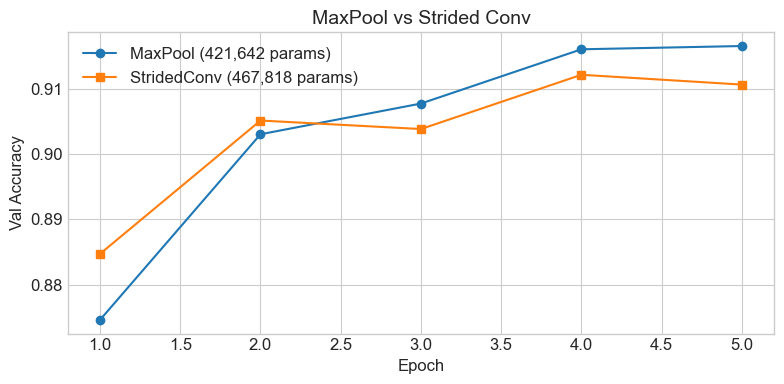

In [7]:
# Задача 6. MaxPool vs Strided Conv

torch.manual_seed(SEED)

# Вариант A: классический подход — свёртка + MaxPool2d(2)
class CNN_MaxPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # (B,32,14,14)
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # (B,64,7,7)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

# Вариант B: замена MaxPool на Conv2d с stride=2
# Strided conv одновременно понижает разрешение и учит фильтры — больше параметров
class CNN_StridedConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.ReLU(),   # (B,32,14,14) — заменяет MaxPool
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),   # (B,64,7,7) — заменяет MaxPool
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


def train_and_eval(model, name, epochs=5):
    """Универсальный цикл обучения + оценка на тесте. Возвращает val_acc по эпохам."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    val_accs = []

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

        # Валидация
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total += y_b.size(0)
        acc = correct / total
        val_accs.append(acc)
        print(f"  Epoch {epoch+1}/{epochs}  val_acc={acc:.4f}")

    # Тест
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            correct += (model(X_b).argmax(1) == y_b).sum().item()
            total += y_b.size(0)
    test_acc = correct / total
    print(f"  Test accuracy: {test_acc:.4f}")
    return val_accs, test_acc


print("--- Вариант A: MaxPool ---")
m_a = CNN_MaxPool()
accs_a, test_a = train_and_eval(m_a, "MaxPool", 5)

print("\n--- Вариант B: Strided Conv ---")
m_b = CNN_StridedConv()
accs_b, test_b = train_and_eval(m_b, "StridedConv", 5)

p_a = sum(p.numel() for p in m_a.parameters())
p_b = sum(p.numel() for p in m_b.parameters())

print(f"\nПараметры  MaxPool:     {p_a:>8,}")
print(f"Параметры  StridedConv: {p_b:>8,}")
print(f"Accuracy   MaxPool:     {test_a:.4f}")
print(f"Accuracy   StridedConv: {test_b:.4f}")

# График сравнения
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), accs_a, 'o-', label=f'MaxPool ({p_a:,} params)')
ax.plot(range(1, 6), accs_b, 's-', label=f'StridedConv ({p_b:,} params)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('MaxPool vs Strided Conv'); ax.legend()
plt.tight_layout(); plt.show()

---

## Задача 7. Эксперимент с padding: same vs valid

### Постановка задачи

Сравните влияние padding на качество классификации и размер карт признаков.

### Задача
1. Модель A: padding=1 (same) во всех свертках.
2. Модель B: padding=0 (valid).
3. Обучите обе на FashionMNIST (5 эпох).
4. Сравните размеры промежуточных тензоров и accuracy.


Размерности карт признаков:
  Same (p=1):  features → [1, 64, 7, 7]  →  flatten=3136
  Valid (p=0): features → [1, 64, 5, 5]  →  flatten=1600

--- Вариант Same (padding=1) ---
  Epoch 1/5  val_acc=0.8716
  Epoch 2/5  val_acc=0.8840
  Epoch 3/5  val_acc=0.9159
  Epoch 4/5  val_acc=0.9158
  Epoch 5/5  val_acc=0.9110
  Test accuracy: 0.9062

--- Вариант Valid (padding=0) ---
  Epoch 1/5  val_acc=0.8654
  Epoch 2/5  val_acc=0.8879
  Epoch 3/5  val_acc=0.8987
  Epoch 4/5  val_acc=0.9056
  Epoch 5/5  val_acc=0.9100
  Test accuracy: 0.9037

Параметры Same:   421,642
Параметры Valid:  225,034
Accuracy  Same:  0.9062
Accuracy  Valid: 0.9037

Вывод: padding=0 уменьшает размер карт признаков, что приводит
к потере информации на краях изображения. Для небольших входов это критично.


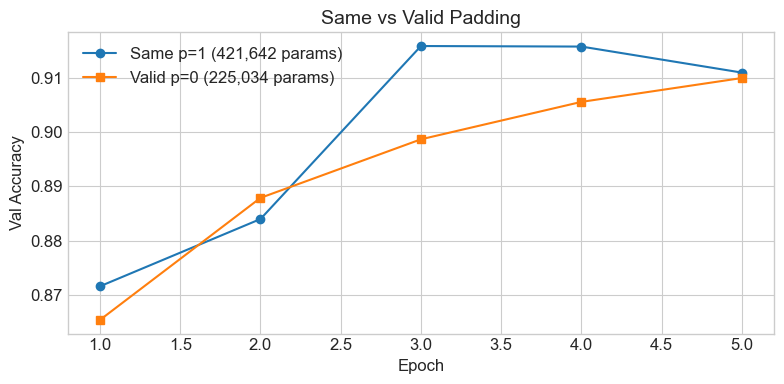

In [8]:
# Задача 7. Padding same vs valid

torch.manual_seed(SEED)

# Вариант Same: padding=1 сохраняет пространственные размеры после свёртки
# 28→28(conv)→14(pool)→14(conv)→7(pool) => (B,64,7,7) => flatten=3136
class CNN_Same(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # (B,32,14,14)
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # (B,64,7,7)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

# Вариант Valid: padding=0 — каждая свёртка уменьшает карту на (k-1)
# 28→26(conv)→13(pool)→11(conv)→5(pool) => (B,64,5,5) => flatten=1600
class CNN_Valid(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=0), nn.ReLU(), nn.MaxPool2d(2),   # (B,32,13,13)
            nn.Conv2d(32, 64, 3, padding=0), nn.ReLU(), nn.MaxPool2d(2),  # (B,64,5,5)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


# Проверка размерностей
x_test = torch.randn(1, 1, 28, 28)

m_same_check = CNN_Same()
m_valid_check = CNN_Valid()

# Прогон через feature extractor для наглядности
with torch.no_grad():
    feat_same = m_same_check.features(x_test)
    feat_valid = m_valid_check.features(x_test)

print("Размерности карт признаков:")
print(f"  Same (p=1):  features → {list(feat_same.shape)}  →  flatten={feat_same.numel()}")
print(f"  Valid (p=0): features → {list(feat_valid.shape)}  →  flatten={feat_valid.numel()}")

print("\n--- Вариант Same (padding=1) ---")
m_same = CNN_Same()
accs_same, test_same = train_and_eval(m_same, "Same", 5)

print("\n--- Вариант Valid (padding=0) ---")
m_valid = CNN_Valid()
accs_valid, test_valid = train_and_eval(m_valid, "Valid", 5)

p_same  = sum(p.numel() for p in m_same.parameters())
p_valid = sum(p.numel() for p in m_valid.parameters())

print(f"\nПараметры Same:  {p_same:>8,}")
print(f"Параметры Valid: {p_valid:>8,}")
print(f"Accuracy  Same:  {test_same:.4f}")
print(f"Accuracy  Valid: {test_valid:.4f}")
print("\nВывод: padding=0 уменьшает размер карт признаков, что приводит")
print("к потере информации на краях изображения. Для небольших входов это критично.")

# График сравнения
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), accs_same, 'o-', label=f'Same p=1 ({p_same:,} params)')
ax.plot(range(1, 6), accs_valid, 's-', label=f'Valid p=0 ({p_valid:,} params)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Same vs Valid Padding'); ax.legend()
plt.tight_layout(); plt.show()

---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Детекция и сегментация на синтетических данных.

## Задача 8. Toy Detection: регрессия Bounding Box

### Постановка задачи

Генерируются синтетические 64x64 изображения с одним прямоугольником
в случайной позиции. Модель предсказывает координаты Bounding Box.

### Задача
1. Сгенерируйте 1000 train и 200 test изображений.
2. Реализуйте CNN для регрессии: выход — 4 числа (x, y, w, h), нормализованных в [0, 1].
3. Loss: MSE.  Метрика: IoU.
4. Обучите 30 эпох.
5. Визуализируйте 6 примеров с истинным и предсказанным bbox.


Train: torch.Size([1000, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])
Epoch  5/30  loss=0.00038  train_IoU=0.8312
Epoch 10/30  loss=0.00008  train_IoU=0.9089
Epoch 15/30  loss=0.00004  train_IoU=0.9277
Epoch 20/30  loss=0.00004  train_IoU=0.9407
Epoch 25/30  loss=0.00002  train_IoU=0.9397
Epoch 30/30  loss=0.00004  train_IoU=0.9474


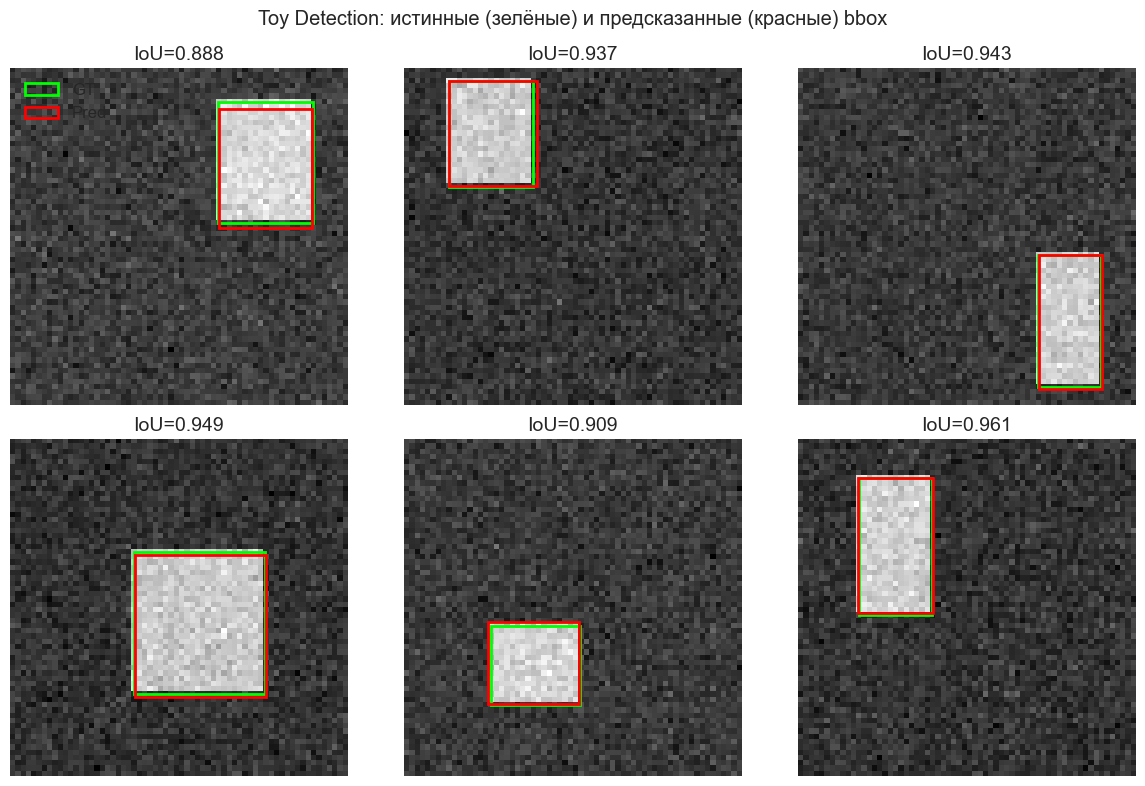


Средний IoU на тесте: 0.9275


In [9]:
# Задача 8. Toy Detection

torch.manual_seed(SEED)
np.random.seed(SEED)

def generate_detection_data(n, img_size=64):
    """Генерирует изображения с одним прямоугольником и bbox-таргетом."""
    images, bboxes = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        # Случайный прямоугольник
        w = np.random.randint(10, 30)
        h = np.random.randint(10, 30)
        x = np.random.randint(0, img_size - w)
        y = np.random.randint(0, img_size - h)
        img[y:y+h, x:x+w] = 1.0
        # Добавляем шум
        img += 0.1 * np.random.randn(img_size, img_size).astype(np.float32)
        images.append(img)
        # bbox в формате (cx, cy, w, h), нормализованный к [0, 1]
        cx = (x + w / 2) / img_size
        cy = (y + h / 2) / img_size
        bboxes.append([cx, cy, w / img_size, h / img_size])
    X = torch.tensor(np.array(images)).unsqueeze(1)              # (N,1,64,64)
    Y = torch.tensor(np.array(bboxes), dtype=torch.float32)      # (N,4)
    return X, Y

X_train, Y_train = generate_detection_data(1000)
X_test,  Y_test  = generate_detection_data(200)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_det_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)

# --- IoU ---
def compute_iou(pred, target):
    """Вычисляет средний IoU для bbox в формате (cx, cy, w, h), нормализованных."""
    # Переход к (x1, y1, x2, y2)
    pred_x1 = pred[:, 0] - pred[:, 2] / 2
    pred_y1 = pred[:, 1] - pred[:, 3] / 2
    pred_x2 = pred[:, 0] + pred[:, 2] / 2
    pred_y2 = pred[:, 1] + pred[:, 3] / 2

    tgt_x1 = target[:, 0] - target[:, 2] / 2
    tgt_y1 = target[:, 1] - target[:, 3] / 2
    tgt_x2 = target[:, 0] + target[:, 2] / 2
    tgt_y2 = target[:, 1] + target[:, 3] / 2

    # Пересечение
    inter_x1 = torch.max(pred_x1, tgt_x1)
    inter_y1 = torch.max(pred_y1, tgt_y1)
    inter_x2 = torch.min(pred_x2, tgt_x2)
    inter_y2 = torch.min(pred_y2, tgt_y2)

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    tgt_area  = (tgt_x2 - tgt_x1) * (tgt_y2 - tgt_y1)
    union_area = pred_area + tgt_area - inter_area

    iou = inter_area / (union_area + 1e-6)
    return iou.mean().item()

# --- Модель ---
# Encoder: 3 свёрточных блока с даунсемплингом
# Head: регрессия 4 координат через sigmoid → [0, 1]
class DetectionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # (B,16,32,32)
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # (B,32,16,16)
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # (B,64,8,8)
        )
        self.head = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 4),
            nn.Sigmoid(),  # bbox координаты в [0, 1]
        )

    def forward(self, x):
        x = self.features(x)       # (B,64,8,8)
        x = x.flatten(start_dim=1) # (B,4096)
        return self.head(x)         # (B,4)

model_det = DetectionCNN().to(device)
optimizer = optim.Adam(model_det.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- Обучение ---
losses = []
for epoch in range(30):
    model_det.train()
    epoch_loss = 0.0
    for X_b, y_b in train_det_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model_det(X_b), y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_b.size(0)
    avg_loss = epoch_loss / len(X_train)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        model_det.eval()
        with torch.no_grad():
            train_iou = compute_iou(model_det(X_train.to(device)).cpu(), Y_train)
        print(f"Epoch {epoch+1:>2}/30  loss={avg_loss:.5f}  train_IoU={train_iou:.4f}")

# --- Визуализация ---
model_det.eval()
with torch.no_grad():
    preds_all = model_det(X_test.to(device)).cpu()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for idx, ax in enumerate(axes.flat):
    img = X_test[idx, 0].numpy()
    ax.imshow(img, cmap='gray')

    # Истинный bbox (зелёный) - .item() для конвертации Tensor → float
    gt = Y_test[idx]
    gx1 = (gt[0] - gt[2] / 2).item() * 64
    gy1 = (gt[1] - gt[3] / 2).item() * 64
    gw, gh = gt[2].item() * 64, gt[3].item() * 64
    rect_gt = patches.Rectangle((gx1, gy1), gw, gh,
                                 linewidth=2, edgecolor='lime', facecolor='none', label='GT')
    ax.add_patch(rect_gt)

    # Предсказанный bbox (красный)
    pr = preds_all[idx]
    px1 = (pr[0] - pr[2] / 2).item() * 64
    py1 = (pr[1] - pr[3] / 2).item() * 64
    pw, ph = pr[2].item() * 64, pr[3].item() * 64
    rect_pr = patches.Rectangle((px1, py1), pw, ph,
                                 linewidth=2, edgecolor='red', facecolor='none', label='Pred')
    ax.add_patch(rect_pr)

    iou_val = compute_iou(pr.unsqueeze(0), gt.unsqueeze(0))
    ax.set_title(f"IoU={iou_val:.3f}")
    ax.axis('off')

axes[0, 0].legend(loc='upper left')
plt.suptitle("Toy Detection: истинные (зелёные) и предсказанные (красные) bbox")
plt.tight_layout(); plt.show()

final_iou = compute_iou(preds_all, Y_test)
print(f"\nСредний IoU на тесте: {final_iou:.4f}")

---

## Задача 9. Toy Segmentation: мини encoder-decoder

### Постановка задачи

Реализуйте сеть типа encoder-decoder со Skip Connections для бинарной
сегментации синтетических изображений.

### Задача
1. Сгенерируйте 800 train и 200 test пар (изображение, маска) с кругами/прямоугольниками.
2. Encoder: 3 уровня (Conv+ReLU+MaxPool).
3. Decoder: 3 уровня (ConvTranspose + Skip Connection + Conv+ReLU).
4. Loss: BCEWithLogitsLoss.  Метрики: IoU, Dice.
5. Обучите 30 эпох.
6. Визуализируйте 6 примеров: вход, истинная маска, предсказанная маска.


Train: torch.Size([800, 1, 64, 64]), Test: torch.Size([200, 1, 64, 64])
Epoch  5/30  loss=0.00224  val_IoU=0.9951
Epoch 10/30  loss=0.00016  val_IoU=0.9999
Epoch 15/30  loss=0.00005  val_IoU=0.9999
Epoch 20/30  loss=0.00003  val_IoU=0.9999
Epoch 25/30  loss=0.00002  val_IoU=0.9999
Epoch 30/30  loss=0.00001  val_IoU=0.9999


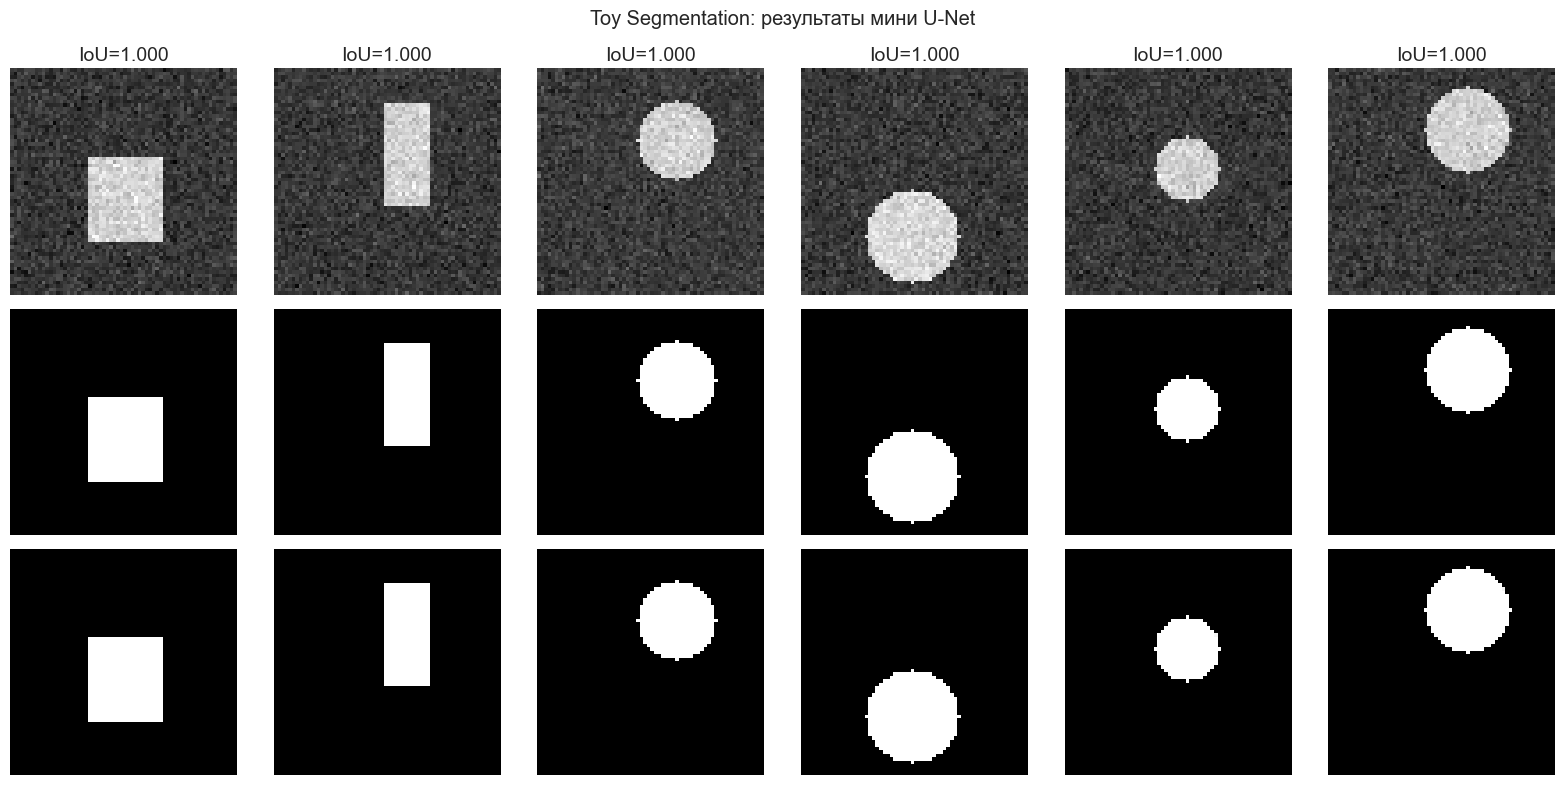


Средний IoU  на тесте: 1.0000
Средний Dice на тесте: 1.0000


In [10]:
# Задача 9. Toy Segmentation: мини encoder-decoder

torch.manual_seed(SEED)
np.random.seed(SEED)

def generate_segmentation_data(n, img_size=64):
    """Генерирует изображения с фигурой и бинарные маски."""
    images, masks = [], []
    for _ in range(n):
        img = np.zeros((img_size, img_size), dtype=np.float32)
        mask = np.zeros((img_size, img_size), dtype=np.float32)
        # Случайно круг или прямоугольник
        if np.random.rand() > 0.5:
            # Круг
            cx, cy = np.random.randint(15, img_size - 15, size=2)
            r = np.random.randint(5, 15)
            yy, xx = np.ogrid[:img_size, :img_size]
            circle = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[circle] = 1.0
            mask[circle] = 1.0
        else:
            # Прямоугольник
            w = np.random.randint(10, 30)
            h = np.random.randint(10, 30)
            x = np.random.randint(0, img_size - w)
            y = np.random.randint(0, img_size - h)
            img[y:y+h, x:x+w] = 1.0
            mask[y:y+h, x:x+w] = 1.0
        # Гауссов шум для реалистичности
        img += 0.1 * np.random.randn(img_size, img_size).astype(np.float32)
        images.append(img)
        masks.append(mask)
    X = torch.tensor(np.array(images)).unsqueeze(1)
    Y = torch.tensor(np.array(masks)).unsqueeze(1)
    return X, Y

X_tr_seg, Y_tr_seg = generate_segmentation_data(800)
X_te_seg, Y_te_seg = generate_segmentation_data(200)
print(f"Train: {X_tr_seg.shape}, Test: {X_te_seg.shape}")

seg_train_loader = DataLoader(TensorDataset(X_tr_seg, Y_tr_seg), batch_size=16, shuffle=True)

# --- Метрики ---
def iou_score(pred_mask, true_mask, threshold=0.5):
    pred_bin = (pred_mask > threshold).float()
    true_bin = true_mask.float()
    intersection = (pred_bin * true_bin).sum()
    union = pred_bin.sum() + true_bin.sum() - intersection
    return (intersection / (union + 1e-6)).item()

def dice_score(pred_mask, true_mask, threshold=0.5):
    pred_bin = (pred_mask > threshold).float()
    true_bin = true_mask.float()
    intersection = (pred_bin * true_bin).sum()
    return (2 * intersection / (pred_bin.sum() + true_bin.sum() + 1e-6)).item()

# --- Мини U-Net ---
# Encoder: 64→32→16→8 (3 уровня даунсемплинга)
# Decoder: 8→16→32→64 (ConvTranspose2d + skip connections)
class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU())    # (B,16,64,64)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())   # (B,32,32,32)
        self.enc3 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())   # (B,64,16,16)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck                                                              # (B,64,8,8)
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU())

        # Decoder (ConvTranspose для апсемплинга + skip → conv для слияния)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)          # → (B,64,16,16)
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())  # skip: 64+64=128 → 64

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)           # → (B,32,32,32)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())   # skip: 32+32=64 → 32

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)           # → (B,16,64,64)
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())   # skip: 16+16=32 → 16

        self.final = nn.Conv2d(16, 1, kernel_size=1)  # 1×1 conv → логиты

    def forward(self, x):
        # Encoder path с сохранением skip connections
        e1 = self.enc1(x)                # (B,16,64,64)
        e2 = self.enc2(self.pool(e1))    # (B,32,32,32)
        e3 = self.enc3(self.pool(e2))    # (B,64,16,16)

        b = self.bottleneck(self.pool(e3))  # (B,128,8,8)

        # Decoder path: upsample → concat skip → conv
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))    # (B,64,16,16)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))   # (B,32,32,32)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))   # (B,16,64,64)

        return self.final(d1)  # (B,1,64,64) — логиты

model_seg = MiniUNet().to(device)
optimizer = optim.Adam(model_seg.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# --- Обучение ---
seg_losses = []
for epoch in range(30):
    model_seg.train()
    epoch_loss = 0.0
    for X_b, y_b in seg_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model_seg(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_b.size(0)
    avg_loss = epoch_loss / len(X_tr_seg)
    seg_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        model_seg.eval()
        with torch.no_grad():
            val_pred = torch.sigmoid(model_seg(X_te_seg[:50].to(device))).cpu()
        val_iou = np.mean([iou_score(val_pred[i], Y_te_seg[i]) for i in range(50)])
        print(f"Epoch {epoch+1:>2}/30  loss={avg_loss:.5f}  val_IoU={val_iou:.4f}")

# --- Визуализация ---
model_seg.eval()
with torch.no_grad():
    pred_masks = torch.sigmoid(model_seg(X_te_seg.to(device))).cpu()

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
titles_row = ["Вход", "Истинная маска", "Предсказанная маска"]

for col in range(6):
    axes[0, col].imshow(X_te_seg[col, 0].numpy(), cmap='gray')
    axes[0, col].axis('off')

    axes[1, col].imshow(Y_te_seg[col, 0].numpy(), cmap='gray')
    axes[1, col].axis('off')

    axes[2, col].imshow(pred_masks[col, 0].numpy(), cmap='gray')
    axes[2, col].axis('off')

    iou_val = iou_score(pred_masks[col], Y_te_seg[col])
    axes[0, col].set_title(f"IoU={iou_val:.3f}")

for row, title in enumerate(titles_row):
    axes[row, 0].set_ylabel(title, fontsize=11, rotation=90, labelpad=40)

plt.suptitle("Toy Segmentation: результаты мини U-Net")
plt.tight_layout(); plt.show()

# Средние метрики
ious  = [iou_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
dices = [dice_score(pred_masks[i], Y_te_seg[i]) for i in range(len(Y_te_seg))]
print(f"\nСредний IoU  на тесте: {np.mean(ious):.4f}")
print(f"Средний Dice на тесте: {np.mean(dices):.4f}")